# एसआरए निर्णय ट्रांसफार्मर: रूटिंग विश्लेषण

इस डेमो में, हम सुदृढीकरण सीखने के लिए एसआरए को **निर्णय ट्रांसफार्मर (डीटी)** के रूप में उपयोग करते हैं, और जब एक एजेंट विभिन्न ग्रिडवर्ल्ड कार्यों (उदाहरण के लिए, खजाने की खोज, पलायन) को हल करता है तो 'मस्तिष्क उपयोग' का विश्लेषण करता है।

यहां हम दो बिंदुओं की कल्पना करते हैं:
1. **कार्य पृथक्करण**: 'एस्केप' और 'ट्रेजर' में प्रयुक्त सिनैप्स का पूर्वाग्रह।
2. **धारणा और क्रिया का पृथक्करण**: इनपुट टोकन प्रकारों के आधार पर निर्दिष्ट सिनेप्स कैसे बदलता है: 'स्टेट', 'रिवार्ड' और 'एक्शन'।

## 1. पर्यावरण व्यवस्था

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. मॉडल और कार्य तैयार करें
16 विशेषज्ञों (सिनैप्स) के साथ एक मॉडल परिभाषित करें।

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.sra_language_models import MoESRALanguageModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_gridworld import generate_trajectory, make_dt_batch
from src.sra_experiment import make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=16, # Prepare 16 experts
    k=2,
    max_seq_len=64
)
model = MoESRALanguageModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128, max_seq_len=200, pad_idx=0).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. मिनी ट्रेनिंग लूप
`treasure` और`escape`के लिए बेतरतीब ढंग से प्रक्षेप पथ उत्पन्न करें, और केवल 50 चरणों के लिए प्रशिक्षण लें।(छोटा रखा गया है ताकि यह कोलाब पर जल्दी खत्म हो जाए)

In [3]:
print("Training Decision Transformer...")
model.train()

epochs = 150
batch_size = 32
max_steps = 10

for epoch in range(epochs):
    x, y, _ = make_dt_batch(batch_size, max_steps, device)
    
    optimizer.zero_grad()
    outputs, routing_weights = model(x)
    
    # Calculate loss only for action predictions
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1), ignore_index=-100)
    
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

print("Training finished!")

Training Decision Transformer...


Epoch 50/150 | Loss: 0.9857


Epoch 100/150 | Loss: 0.8416


Epoch 150/150 | Loss: 0.7738
Training finished!


## 4. रूटिंग विश्लेषण: प्रति कार्य सिनैप्स उपयोग
प्रशिक्षण के बाद, एकत्रित करें और तुलना करें कि राउटर 'ट्रेजर' और 'एस्केप' के लिए कौन से सिनैप्स का प्राथमिकता से उपयोग करता है।

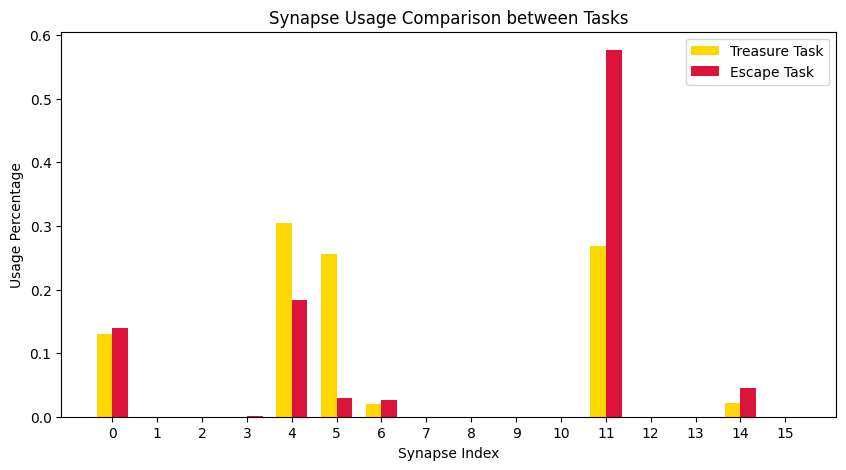

💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).
The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.


In [4]:
def analyze_task_usage(task_type, samples=50):
    model.eval()
    usage_counts = torch.zeros(config.num_synapses, device=device)
    
    with torch.no_grad():
        for _ in range(samples):
            traj = generate_trajectory(task_type, max_steps=5)
            x = torch.tensor([traj], dtype=torch.long).to(device)
            _, routing_weights = model(x)
            
            # Aggregate the indices of synapses used in the final layer's routing
            layer_weights = routing_weights[-1][0]  # [seq_len, n_synapses]
            chosen = layer_weights.argmax(dim=-1)
            usage_counts += torch.bincount(chosen, minlength=config.num_synapses)
            
    usage_pct = (usage_counts / usage_counts.sum()).cpu().numpy()
    return usage_pct

usage_treasure = analyze_task_usage("treasure")
usage_escape = analyze_task_usage("escape")

# Compare using a bar chart
plt.figure(figsize=(10, 5))
x = np.arange(config.num_synapses)
width = 0.35

plt.bar(x - width/2, usage_treasure, width, label='Treasure Task', color='gold')
plt.bar(x + width/2, usage_escape, width, label='Escape Task', color='crimson')

plt.ylabel('Usage Percentage')
plt.xlabel('Synapse Index')
plt.title('Synapse Usage Comparison between Tasks')
plt.xticks(x)
plt.legend()
plt.show()

print("💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).")
print("The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.")

## 5. रूटिंग विश्लेषण: धारणा और क्रिया का पृथक्करण (टोकन-वार विज़ुअलाइज़ेशन)
एकल 'खजाना' प्रक्षेपवक्र के लिए, हीटमैप के माध्यम से जांचें कि राज्य, पुरस्कार और कार्रवाई के लिए प्रत्येक टोकन को कौन सा सिनेप्स सौंपा गया था।

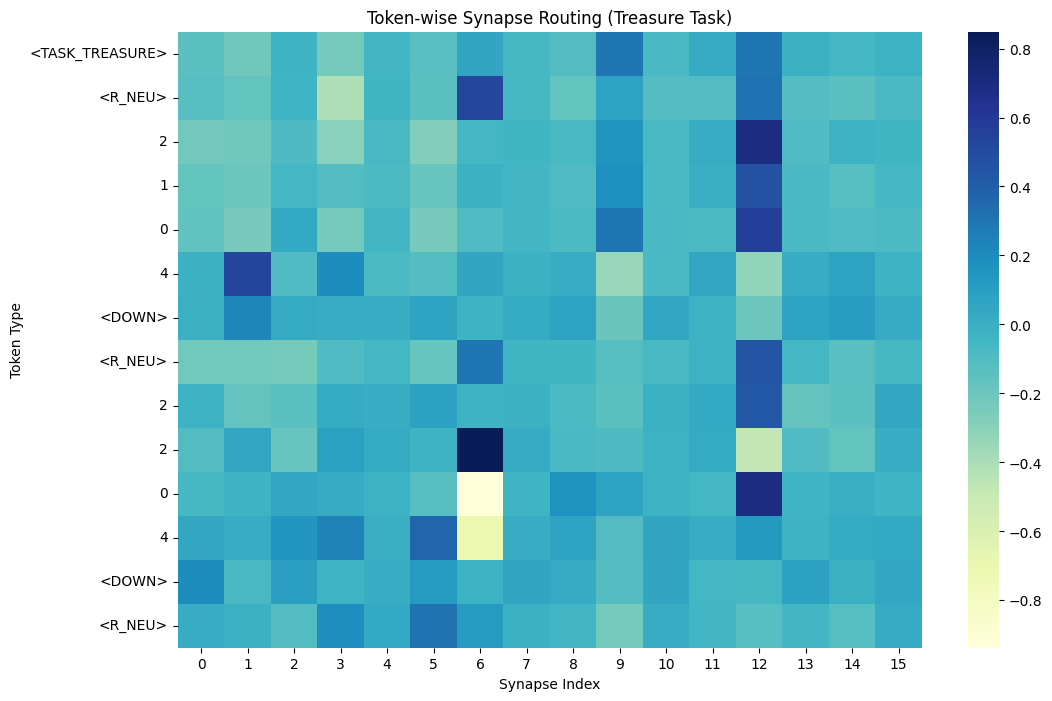

💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',
the darker synapses (horizontal axis) are cleanly separated.


In [5]:
model.eval()
traj = generate_trajectory("treasure", max_steps=2)
x = torch.tensor([traj], dtype=torch.long).to(device)

with torch.no_grad():
    _, routing_weights = model(x)

weights = routing_weights[0][0].cpu().numpy()
from src.constants import ID2TOK
labels = [ID2TOK.get(t, str(t)) for t in traj]

plt.figure(figsize=(12, 8))
sns.heatmap(weights, cmap="YlGnBu", yticklabels=labels, annot=False)
plt.title("Token-wise Synapse Routing (Treasure Task)")
plt.xlabel("Synapse Index")
plt.ylabel("Token Type")
plt.show()

print("💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',")
print("the darker synapses (horizontal axis) are cleanly separated.")